# Finite Elemente Methode in 2D

Im Folgenden wird die mathematische Erklärung des FEM 2D Programms sowie die physikalische Interpretation geliefert. Die physikalische Interpretation hängt davon ab welches Feldproblem man betrachtet. hier: Elektrostatik Es baut auf dem 1D-Notebook auf. Trotz geänderter Geometrie bleibt der konzeptuelle Ablauf Identisch:

1. Erstellung eines Meshs
2. Bestimmung der Randwerte und Materialfunktionen 
3. Schwache Form der PDE

## Die zweidimensionale Randwertaufgabe:
 
$$-\frac{\partial}{\partial x}\left(\alpha_1(x,y)\,\frac{\partial\Phi}{\partial x}\right) - \frac{\partial}{\partial y}\left(\alpha_2(x,y)\,\frac{\partial\Phi}{\partial y}\right) + \beta(x,y)\,\Phi = f(x,y), \quad (x,y)\in G$$

mit Dirichlet-Randbedingungen $\Phi|_{\partial G} = \phi_{\text{Dirichlet}}(x,y)$ auf dem Rand des Gebiets $G \subset \mathbb{R}^2$.

**Konkretes Beispiel:** Bei anisotropen Materialfunktionen gilt ($\alpha_1\neq\alpha_2$), einen Reaktionsterm  und einen Quellterm:                 

$$\alpha_1(x,y) = xy + 1, \quad \alpha_2(x,y) = x + y + 1$$
$$\beta(x,y) = 2x^2, \quad f(x,y) = x + y^2$$
$$\phi_{\text{Dirichlet}}(x,y) = x^2 + y$$

| Term | Mathematisch | Physik (hier: Elektrostatik)|
|---|---|---|
| **Diffusionsterm** $-\nabla\cdot(\alpha\nabla\Phi)$ | $\alpha$ gewichtet den Gradient (richtungsabhängig = anisotrop falls $\alpha_1\neq\alpha_2$) |  $\nabla\mathbf{D}$ (Flussbilanz durch anisotropes Dielektrikum, wobei gilt: $\alpha=\varepsilon_r$: Permittivität. $\mathbf{E}=-\nabla\Phi$, $\mathbf{D}=\varepsilon_r\nabla\Phi$.  |
| **Reaktionsterm** $+\beta\,\Phi$ | Lokale Rückkopplung ohne Gradient. $\beta>0$: bessere Kondition. | $\beta\propto\sigma/\omega\varepsilon$: Verlustfaktor. Debye-Abschirmung durch freie Ladungsträger. In reiner Elektrostatik: $\beta=0$. |
| **Quellterm** $f(x,y)$ | Rechte Seite (Inhomogenität), unabhängig von $\Phi$. | Freie Ladungsdichte $\rho_\text{f}$. | 

## Was sich gegenüber 1D ändert

| Aspekt | 1D | 2D |
|---|---|---|
| Gebiet | Intervall $[a,b]$ | Fläche $G$ |
| Knotenkoordinaten | $x_i$ (skalar) | $(x_i, y_i)$ (2D-Punkt) |
| Elemente | Intervalle (2 Knoten) | Dreiecke (3 Knoten) |
| Hutfunktionen | lineare Spitzen | Pyramiden |
| Lokale Matrix | $2\times 2$ | $3\times 3$ |
| Ableitung | $d/dx$ | $\nabla = (\partial_x, \partial_y)$ |
| Integral | $\int dx$ | $\iint dA$ |

**Was identisch bleibt:** Schwache Form, Galerkin-Ansatz, Element-Assembly mit `+=`, Dirichlet-Reduktion, LGS lösen.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import lil_matrix, csr_matrix
from scipy.sparse.linalg import spsolve

---
## 2. Materialfunktionen und Randbedingungen

Die DGL enthält jetzt **zwei** Diffusionskoeffizienten ($\alpha_1$ für die $x$-Richtung, $\alpha_2$ für die $y$-Richtung). Damit lassen sich auch **anisotrope** Probleme behandeln, also Materialien, die in unterschiedliche Richtungen verschieden auf Felder reagieren.

### Physikalische Interpretation

Die DGL
$$-\nabla\cdot(\boldsymbol{\alpha}\,\nabla\Phi) + \beta\,\Phi = f$$
mit dem Tensor $\boldsymbol{\alpha} = \text{diag}(\alpha_1, \alpha_2)$ deckt verschiedene Anwendungen ab:

**Elektrostatik in anisotropem Dielektrikum:**
- $\alpha_1, \alpha_2$ = $\varepsilon_x$, $\varepsilon_y$ : Permittivitäten in $x$- und $y$-Richtung
- $\Phi$ = $\phi$ : elektrisches Potenzial [V]
- $f$ = $\rho$ : Raumladungsdichte [As/m³]

**Wärmeleitung mit richtungsabhängiger Leitfähigkeit** (z.B. in Faserverbundstoffen):
- $\alpha_1, \alpha_2$: Wärmeleitfähigkeiten parallel/senkrecht zur Faser
- $\Phi$: Temperatur

**Helmholtz-Gleichung in 2D** (mit $\beta = -\omega^2\varepsilon\mu$): EM-Wellen in Wellenleitern, Antennen, Resonatoren

### Randbedingungen

$\phi_{\text{Dirichlet}}(x,y)$ ist eine **Funktion** auf dem Rand, die den vorgegebenen Wert von $\Phi$ liefert. Anders als in 1D (wo es nur zwei isolierte Randpunkte gab) ergibt sich eine **kontinuierliche Funktion** entlang einer Randkurve.

In [2]:
# Materialfunktionen und Quellterm (anisotrop, ortsabhängig)
def alpha1(x, y): return y * x + 1     # Diffusionskoeffizient in x-Richtung
def alpha2(x, y): return x + y + 1     # Diffusionskoeffizient in y-Richtung
def beta(x, y):   return 2 * x**2      # Reaktionskoeffizient
def f(x, y):      return x + y**2      # Quellterm

# Dirichlet-Randwertfunktion: gibt den vorgegebenen Wert an jeder Randposition
def phi_dirichlet(x, y): return x**2 + y

---
## 3. Mesh-Definition

Das 2D-Mesh besteht aus:
- **Knoten**: 2D-Punkte $(x_i, y_i)$ in der `p`-Liste
- **Dreieckselemente**: drei Knotenindizes pro Element in der `t`-Liste

### Datenstrukturen

**`p`-Liste:** Jeder Eintrag ist ein **2D-Punkt**:
$$p[i] = [x_i,\ y_i]$$

**`t`-Liste:** Jeder Eintrag enthält **drei** globale Knotennummern (die Ecken des Dreiecks):
$$t[e] = [g_1,\ g_2,\ g_3]$$

### Mesh-Geometrie hier

Wir verwenden ein **handgestricktes Mesh** mit 6 Knoten und 6 Dreiecken über einem rechteckigen Gebiet. Das ist für den Lernanfang ideal da es überschaubar bleibt.
Die Reihenfolge der drei Knoten in `t[e]` definiert die **Orientierung** des Dreiecks. Also in welcher Reihenfolge die Indizes durchlaufen werden (gegen [CCW] oder im Uhrzeigersinn [CW]). Wir nehmen den Absolutbetrag der Fläche, sodass die Orientierung egal ist. Der Vorteil ist, dass man nicht aufpassen muss, ob man die Knoten richtig bzw. konsistent eingibt. Der Preis: man verliert die Vorzeicheninformation, die in manchen Kontexten nützlich sein kann (z.B Normalenvektoren, Überprüfung ob ein Mesh degeneriert ist.) Für die Steifigkeitsmatrix im Galerkin-Verfahren braucht man aber nur die Fläche als positiven Wert also ist $|A_e|$ hier korrekt.

### Dirichlet-Randknoten

Die Liste `dR` enthält die Knoten, die **auf dem Rand** des Gebiets liegen. Hier wählen wir vier äußere Knoten: 0, 4, 3, 5. Die zwei inneren Knoten 1 und 2 bleiben frei und werden vom Solver berechnet.

Anzahl Knoten: 6
Anzahl Elemente (Flächen): 6
Dirichlet-Randknoten: [0, 4, 3, 5]
Innere Knoten: [1, 2]


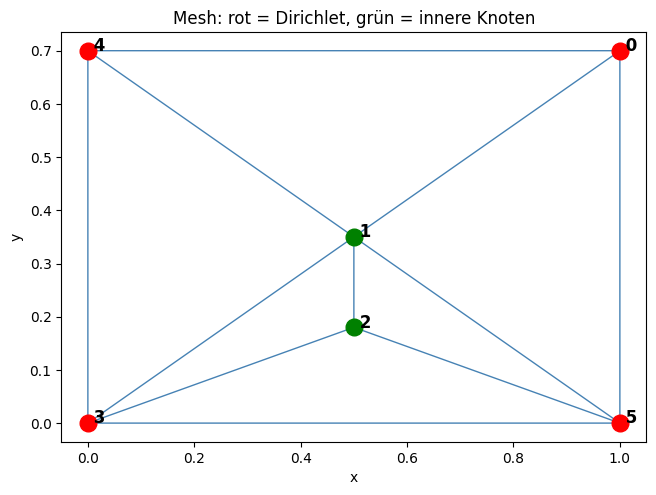

In [3]:
# Knotenkoordinaten als Liste von [x, y]-Paaren
p = [[1, 0.7],     # Knoten 0
     [0.5, 0.35],  # Knoten 1 (innen)
     [0.5, 0.18],  # Knoten 2 (innen)
     [0, 0],       # Knoten 3
     [0, 0.7],     # Knoten 4
     [1, 0]]       # Knoten 5

# Element-Konnektivität: jedes Dreieck mit drei Knotennummern
t = [[0, 4, 1],    # Element 0
     [3, 1, 4],    # Element 1
     [5, 0, 1],    # Element 2
     [3, 5, 2],    # Element 3
     [2, 1, 3],    # Element 4
     [5, 1, 2]]    # Element 5

# Dirichlet-Randknoten (Indizes der Knoten auf dem Rand)
dR = [0, 4, 3, 5]

# Umwandlung zu NumPy-Array für effizientes Indizieren
p = np.array(p, dtype=float)
N = len(p)

print(f"Anzahl Knoten: {N}")
print(f"Anzahl Elemente (Flächen): {len(t)}")
print(f"Dirichlet-Randknoten: {dR}")
print(f"Innere Knoten: {[i for i in range(N) if i not in dR]}")

# Mesh visualisieren
fig, ax = plt.subplots(figsize=(7, 5))
ax.triplot(p[:, 0], p[:, 1], t, color='steelblue', linewidth=1)
for i, (x, y) in enumerate(p):
    color = 'red' if i in dR else 'green'
    ax.plot(x, y, 'o', color=color, markersize=12)
    ax.annotate(f' {i}', (x, y), fontsize=12, fontweight='bold')
ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title('Mesh: rot = Dirichlet, grün = innere Knoten')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

---
## 4. Schwache Form in 2D

Die schwache Form ergibt sich durch Multiplikation der DGL mit einer Testfunktion $v(x,y)$ und Integration über das Gebiet $G$, gefolgt von **partieller Integration** (in 2D als Anwendung des Gauß'schen Integralsatzes):

$$\iint_G \left[\alpha_1\,\frac{\partial v}{\partial x}\,\frac{\partial\Phi}{\partial x} + \alpha_2\,\frac{\partial v}{\partial y}\,\frac{\partial\Phi}{\partial y}\right]dA + \iint_G \beta\,v\,\Phi\,dA = \iint_G v\,f\,dA + \underbrace{\oint_{\partial G} v\,(\boldsymbol{\alpha}\nabla\Phi)\cdot \mathbf{n}\,ds}_{\text{Randterm (entfällt bei Dirichlet)}}$$

### Kompakter geschrieben mit Gradienten

Mit $\nabla = (\partial_x, \partial_y)$ und dem Materialtensor $\boldsymbol{\alpha} = \text{diag}(\alpha_1, \alpha_2)$:

$$\iint_G (\nabla v) \cdot (\boldsymbol{\alpha}\nabla\Phi)\,dA + \iint_G \beta\,v\,\Phi\,dA = \iint_G v\,f\,dA$$

Das ist die natürliche 2D-Verallgemeinerung der 1D-Form $\int \alpha\,v'\,\Phi'\,dx + \int \beta\,v\,\Phi\,dx = \int v\,f\,dx$.

### Galerkin-Diskretisierung

Ansatz $\tilde\Phi = \sum_j \Phi_j\,N_j(x,y)$, Testfunktion $v = N_k$. Das ergibt das LGS:

$$\sum_j K_{kj}\,\Phi_j = D_k$$

mit

$$K_{kj} = \iint_G \left(\alpha_1\,\frac{\partial N_k}{\partial x}\,\frac{\partial N_j}{\partial x} + \alpha_2\,\frac{\partial N_k}{\partial y}\,\frac{\partial N_j}{\partial y}\right)dA + \iint_G \beta\,N_k\,N_j\,dA$$

$$D_k = \iint_G N_k\,f\,dA$$

---
## 5. Lineare Hutfunktionen auf einem Dreieck

Auf einem Dreieck mit Ecken $(x_1, y_1), (x_2, y_2), (x_3, y_3)$ definieren wir **drei lokale Hutfunktionen** $N_1, N_2, N_3$ mit den Eigenschaften:

$$N_l(x_m, y_m) = \delta_{lm} = \begin{cases} 1 & l = m \\ 0 & l \neq m\end{cases}$$

Außerdem: **Partition of Unity** $N_1 + N_2 + N_3 = 1$ überall im Dreieck.

### Explizite Form

Die lineare Hutfunktion lautet:
$$N_l(x,y) = \frac{1}{2A}(a_l + b_l\,x + c_l\,y)$$

mit der **doppelten Dreiecksfläche** $2A$ und den Koeffizienten:

$$b_l = y_m - y_n, \quad c_l = x_n - x_m$$

(wobei $(l, m, n)$ eine zyklische Permutation von $(1, 2, 3)$ ist).

### Die Schlüsselformel: Konstante Gradienten!

Die Ableitungen der linearen Hutfunktion sind **konstant** über das ganze Dreieck:

$$\frac{\partial N_l}{\partial x} = \frac{b_l}{2A}, \qquad \frac{\partial N_l}{\partial y} = \frac{c_l}{2A}$$

Das ist die **direkte Verallgemeinerung** der 1D-Eigenschaft, dass lineare Hutfunktionen konstante Ableitungen haben. Genauso wie in 1D macht diese Konstanz die Integrale der Steifigkeitsmatrix zu **Schul-Mathematik** — keine Quadratur nötig für den Steifigkeitsanteil.

### Dreiecksfläche

Die **doppelte signierte Fläche** des Dreiecks ist:
$$2A = (x_2 - x_1)(y_3 - y_1) - (x_3 - x_1)(y_2 - y_1)$$

Das ist die Determinante der Koordinatentransformation vom Referenzdreieck zum aktuellen Dreieck. Wir nehmen den Absolutbetrag, sodass die Knotenreihenfolge in `t[e]` keine Rolle spielt.

---
## 6. Theorie — Lokale Element-Matrix (3×3)

Auf einem Dreieckselement berechnen wir die **lokale 3×3-Matrix**:
$$\mathcal{K}^{(e)}_{lm} = \iint_{E_e}\left(\alpha_1\,\frac{\partial N_l}{\partial x}\,\frac{\partial N_m}{\partial x} + \alpha_2\,\frac{\partial N_l}{\partial y}\,\frac{\partial N_m}{\partial y}\right)dA + \iint_{E_e}\beta\,N_l\,N_m\,dA$$

### Steifigkeitsanteil (mit Mittelpunktsregel)

Da die Gradienten konstant sind und wir $\alpha_1, \alpha_2$ am Schwerpunkt auswerten:

$$\iint_{E_e}\alpha_1\,\partial_x N_l\,\partial_x N_m\,dA \approx \alpha_1(x_M, y_M)\cdot\frac{b_l\,b_m}{(2A)^2}\cdot A = \frac{\alpha_1(x_M, y_M)\,b_l\,b_m}{2(2A)}$$

(weil $\iint dA = A$ und $(2A)^2 = 4A^2 \to$ Faktor $1/(4A) \cdot A = 1/4$, dann nochmal mal 2 aus dem Nenner).

Vereinfacht zur **finalen Formel**:

$$\boxed{\text{Steifigkeitsanteil} = \frac{\alpha_1(x_M, y_M)\,b_l\,b_m + \alpha_2(x_M, y_M)\,c_l\,c_m}{2\,(2A)}}$$

### Massenanteil (analytisch exakt)

Für die Integrale $\iint N_l\,N_m\,dA$ über ein Dreieck gibt es **exakte analytische Formeln**:

$$\iint_{E_e} N_l\,N_m\,dA = \begin{cases}\dfrac{A}{6} & l = m \\ \dfrac{A}{12} & l \neq m\end{cases}$$

Mit Mittelpunktsregel für $\beta$ und $A = (2A)/2$:

$$\boxed{\text{Massenanteil} = \begin{cases}\dfrac{\beta(x_M, y_M)\,(2A)}{12} & l = m \\ \dfrac{\beta(x_M, y_M)\,(2A)}{24} & l \neq m\end{cases}}$$

### Lokaler Lastvektor

Mit Schwerpunktsregel:
$$\mathcal{D}_l = \iint_{E_e} N_l\,f\,dA \approx f(x_M, y_M)\cdot\iint N_l\,dA = \frac{f(x_M, y_M)\,A}{3} = \frac{f(x_M, y_M)\,(2A)}{6}$$

Die Quelle wird zu **gleichen Teilen** auf alle drei Knoten verteilt — analog zu 1D, wo sie auf zwei Knoten verteilt wurde.

### Vergleich 1D ↔ 2D

| Größe | 1D | 2D |
|---|---|---|
| Lokale Matrix | $2\times 2$ | $3\times 3$ |
| Anzahl Integrale | 4 | 9 |
| Steifigkeit (Diagonale) | $\alpha/L_E$ | $(\alpha_1 b_l^2 + \alpha_2 c_l^2)/(2\cdot 2A)$ |
| Masse (Diagonale) | $L_E\beta/3$ | $\beta\,(2A)/12$ |
| Masse (off-diag) | $L_E\beta/6$ | $\beta\,(2A)/24$ |
| Last pro Knoten | $L_E f/2$ | $(2A)\,f/6$ |

---
## 7. Sparse-Matrix

Bei 2D-Problemen wird die Matrix schnell sehr groß (Tausende Knoten = Millionen potenzielle Einträge), aber **dünn besetzt** — nur Knoten, die durch ein Element verbunden sind, kommen überhaupt als Nicht-Null-Eintrag in Frage.

**`lil_matrix`** (List of Lists): effizient für das **inkrementelle Befüllen** während des Element-Loops. Hier können wir billig `K[i,j] += ...` machen.

Später konvertieren wir zu **`csr_matrix`** (Compressed Sparse Row), das effizient für Solver und Spaltenextraktion ist.

### Speicherersparnis

Eine dichte $1000\times 1000$-Matrix benötigt $10^6 \cdot 8\,\text{Bytes} = 8\,\text{MB}$. Bei einer typischen FEM-Matrix mit ca. 10 Nicht-Null-Einträgen pro Zeile sind das nur $\sim 0.1\,\text{MB}$ — **Faktor 80** Ersparnis!

In [4]:
# Globale Steifigkeitsmatrix als Sparse-Matrix (lil-Format für effizientes Befüllen)
K = lil_matrix((N, N))
D = np.zeros(N)

print(f"Sparse-Matrix K: {K.shape}, Format: {K.format}")
print(f"Lastvektor D: {D.shape}")

Sparse-Matrix K: (6, 6), Format: lil
Lastvektor D: (6,)


---
## 8. Element-Loop und Assembly

Das **Herzstück** der 2D-FEM. Für jedes Dreieckselement:

1. **Knotenkoordinaten** $(x_l, y_l)$ für $l = 1, 2, 3$ aus `p` holen
2. **Doppelte Fläche** $2A$ berechnen (Determinante der Transformation)
3. **Gradient-Koeffizienten** $b_l, c_l$ aus den Knotenkoordinaten
4. **Materialfunktionen** am Schwerpunkt $(x_M, y_M)$ auswerten
5. **Lokale 3×3-Matrix** und **lokalen 3×1-Lastvektor** berechnen
6. **Assembly**: lokale Beiträge in globale Matrix einsortieren (mit `+=`)

### Die zwei verschachtelten Schleifen

Der innere Doppel-Loop über `k, j` durchläuft alle **9 Einträge** der lokalen 3×3-Matrix. In 1D waren es vier (2×2 Matrix), in 2D sind es neun (3×3 Matrix), in 3D wären es 16 (4×4 für Tetraeder).

### Schwerpunktsregel als Quadratur

Wir verwenden die **Schwerpunktsregel** (1-Punkt-Quadratur), bei der wir die Materialfunktionen am **Schwerpunkt** des Dreiecks auswerten:
$$x_M = \frac{x_1 + x_2 + x_3}{3}, \quad y_M = \frac{y_1 + y_2 + y_3}{3}$$

Das ist die einfachste Quadraturregel, exakt für lineare Funktionen, mit Approximationsfehler $\mathcal{O}(h^2)$ für glatte Funktionen.

In [5]:
for elem in t:
    # Globale Knotennummern der 3 lokalen Knoten
    g = elem
    
    # Knotenkoordinaten extrahieren
    x = p[g, 0]    # [x1, x2, x3]
    y = p[g, 1]    # [y1, y2, y3]
    
    # Doppelte (signierte) Fläche des Dreiecks
    # 2A = (x2-x1)(y3-y1) - (x3-x1)(y2-y1)
    A2 = (x[1] - x[0]) * (y[2] - y[0]) - (x[2] - x[0]) * (y[1] - y[0])
    A2 = abs(A2)  # Absolutbetrag → Orientierung der Knotenreihenfolge egal
    
    # Gradient-Koeffizienten der linearen Hutfunktionen
    # grad(N_l) = [b_l, c_l] / (2A)
    # b_l = y_{l+1} - y_{l+2}  (zyklisch)
    # c_l = x_{l+2} - x_{l+1}  (zyklisch)
    b = np.array([y[1] - y[2], y[2] - y[0], y[0] - y[1]])
    c = np.array([x[2] - x[1], x[0] - x[2], x[1] - x[0]])
    
    # Materialfunktionen am Schwerpunkt auswerten
    xM = x.mean()
    yM = y.mean()
    a1M = alpha1(xM, yM)
    a2M = alpha2(xM, yM)
    bM  = beta(xM, yM)
    fM  = f(xM, yM)
    
    #Lokale 3×3-Matrix berechnen (9 Einträge)
    K_local = np.zeros((3, 3))
    for k in range(3):
        for j in range(3):
            # Steifigkeitsanteil: (α1·b_k·b_j + α2·c_k·c_j) / (2·2A)
            stiff = (a1M * b[k] * b[j] + a2M * c[k] * c[j]) / (2 * A2)
            # Massenanteil: 2A/12 auf Diagonale, 2A/24 außerhalb
            mass = bM * A2 / 12 if k == j else bM * A2 / 24
            K_local[k, j] = stiff + mass
    
    # Lokaler Lastvektor: f·2A/6 gleichmäßig auf alle 3 Knoten
    D_local = np.full(3, fM * A2 / 6)
    
    # lokale Beiträge in globale Matrix einsortieren
    for k in range(3):
        D[g[k]] += D_local[k]
        for j in range(3):
            K[g[k], g[j]] += K_local[k, j]

print("Element-Loop abgeschlossen.")
print(f"Anzahl Nicht-Null-Einträge in K: {K.nnz} (von max {N*N} = {N*N})")
print(f"Sparsity: {100*(1 - K.nnz/(N*N)):.1f}% der Einträge sind null")

Element-Loop abgeschlossen.
Anzahl Nicht-Null-Einträge in K: 28 (von max 36 = 36)
Sparsity: 22.2% der Einträge sind null


**Beobachtung zur Sparsity:** Selbst bei diesem winzigen Mesh sind schon einige Einträge null (Knotenpaare, die kein gemeinsames Element haben). Bei größeren Meshes wächst die Sparsity dramatisch — bei 1000 Knoten ist die Matrix typischerweise zu **>99% null**.

---
## 9. Format-Konversion für Solver

Wir konvertieren die `lil_matrix` (gut für Befüllen) zu `csr_matrix` (gut für Solver und Spaltenoperationen). Diese Konvertierung optimiert die interne Datenstruktur für die anschließenden mathematischen Operationen.

In [6]:
K_csr = csr_matrix(K)
print(f"Format konvertiert: {K.format} → {K_csr.format}")

Format konvertiert: lil → csr


---
## 10. Dirichlet-Randbedingungen einbauen

Im Gegensatz zu 1D, wo wir die Dirichlet-Werte direkt vorgegeben hatten, **berechnen** wir sie hier aus der Funktion $\phi_{\text{Dirichlet}}(x, y)$ an den jeweiligen Randknotenpositionen.

Die Strategie ist identisch zu 1D:

**10a.** Bekannte Beiträge auf die rechte Seite verschieben:
$$\mathbf{D} \leftarrow \mathbf{D} - \Phi_d\cdot \mathbf{K}_{:,d}$$

**10b.** Reduziertes System für nur die inneren Knoten aufstellen.

### Warum Sparse-Spaltenextraktion?

`K_csr[:, d]` extrahiert die $d$-te Spalte der Sparse-Matrix als Sparse-Spaltenvektor. Mit `.toarray().ravel()` machen wir daraus ein dichtes 1D-NumPy-Array für die Subtraktion mit `D`. Bei großen Problemen ist das viel effizienter als die ganze Matrix dicht zu machen.

In [7]:
# Dirichlet-Werte aus der Funktion an den Randknotenpositionen berechnen
PhiR = [phi_dirichlet(p[d, 0], p[d, 1]) for d in dR]

print("Dirichlet-Randwerte:")
for d, phi in zip(dR, PhiR):
    print(f"  Knoten {d} bei ({p[d,0]:.2f}, {p[d,1]:.2f}): Phi = {phi:.4f}")

# 10.1. Bekannte Beiträge auf rechte Seite verschieben
for d, phi_d in zip(dR, PhiR):
    D = D - phi_d * K_csr[:, d].toarray().ravel()

# 10.2. Reduziertes System aufstellen
inner_nodes = [i for i in range(N) if i not in dR]
K_reduced = K_csr[np.ix_(inner_nodes, inner_nodes)]
D_reduced = D[inner_nodes]

print(f"\nInnere Knoten: {inner_nodes}")
print(f"Reduzierte Matrix: {K_reduced.shape}")
print(f"Reduzierter Lastvektor: {D_reduced.shape}")

Dirichlet-Randwerte:
  Knoten 0 bei (1.00, 0.70): Phi = 1.7000
  Knoten 4 bei (0.00, 0.70): Phi = 0.7000
  Knoten 3 bei (0.00, 0.00): Phi = 0.0000
  Knoten 5 bei (1.00, 0.00): Phi = 1.0000

Innere Knoten: [1, 2]
Reduzierte Matrix: (2, 2)
Reduzierter Lastvektor: (2,)


---
## 11. Sparse-Solver

Das reduzierte System wird mit `spsolve` aus `scipy.sparse.linalg` gelöst. Dieser Solver nutzt eine **LU-Zerlegung mit Pivotierung** speziell für Sparse-Matrizen und ist deutlich effizienter als der dichte Solver `np.linalg.solve` bei großen Problemen.

### Mathematische Eigenschaften

Wie in 1D ist auch hier die FEM-Matrix **symmetrisch positiv definit** (wegen Galerkin mit selbstadjungiertem Operator). Das garantiert:
- Eindeutige Lösung
- Numerische Stabilität
- Möglichkeit, spezielle effiziente Solver zu verwenden (Cholesky-Zerlegung, CG-Verfahren)

Für kleine Probleme ist `spsolve` mehr als ausreichend.

In [8]:
Phi_inner = spsolve(K_reduced, D_reduced)

print("Berechnete Werte an inneren Knoten:")
for i, node in enumerate(inner_nodes):
    print(f"  Knoten {node} bei ({p[node,0]:.2f}, {p[node,1]:.2f}): Phi = {Phi_inner[i]:.6f}")

Berechnete Werte an inneren Knoten:
  Knoten 1 bei (0.50, 0.35): Phi = 0.896306
  Knoten 2 bei (0.50, 0.18): Phi = 0.711675


---
## 12. Gesamtlösung zusammensetzen

Wie in 1D werden die berechneten Werte (innere Knoten) mit den vorgegebenen Werten (Dirichlet-Knoten) zu einem vollständigen Lösungsvektor kombiniert.

In [9]:
Phi_complete = np.zeros(N)

# Innere Knotenwerte einsortieren
for i, node in enumerate(inner_nodes):
    Phi_complete[node] = Phi_inner[i]

# Dirichlet-Knotenwerte einsortieren
for d, phi_d in zip(dR, PhiR):
    Phi_complete[d] = phi_d

# Tabellarische Ausgabe
print("Knoten | x       | y       | Phi(x,y)  | Typ")
print("-" * 55)
for i in range(N):
    typ = "Dirichlet" if i in dR else "berechnet"
    print(f"{i:5d}  | {p[i,0]:7.3f} | {p[i,1]:7.3f} | {Phi_complete[i]:9.5f}  | {typ}")

Knoten | x       | y       | Phi(x,y)  | Typ
-------------------------------------------------------
    0  |   1.000 |   0.700 |   1.70000  | Dirichlet
    1  |   0.500 |   0.350 |   0.89631  | berechnet
    2  |   0.500 |   0.180 |   0.71167  | berechnet
    3  |   0.000 |   0.000 |   0.00000  | Dirichlet
    4  |   0.000 |   0.700 |   0.70000  | Dirichlet
    5  |   1.000 |   0.000 |   1.00000  | Dirichlet


---
## 13. Visualisierung

In 2D ist die Visualisierung anspruchsvoller. Genutzt werden mehrere Matplotlib-Funktionen:

- **`tricontourf`**: gefüllte Höhenlinien-Darstellung der Lösung über dem Dreiecksmesh
- **`triplot`**: Zeichnet die Dreieckskanten zur Verdeutlichung der Mesh-Struktur
- **Farbskala**: zeigt den Wertebereich von $\Phi$

Die FEM-Lösung ist **stückweise linear** auf jedem Dreieck. Innerhalb eines Dreiecks wird linear interpoliert — analog zu 1D, wo zwischen den Knoten linear interpoliert wurde.

### im Plot zu sehen ist

- **Farbverlauf**: kontinuierlich, weil die linearen Interpolationen über die Dreieckskanten hinweg stetig sind
- **Knicke an Kanten**: leicht sichtbar als geringe Diskontinuitäten in der Steigung
- **Randwerte**: an den Rand-Punkten (rote im Mesh-Plot oben) erfüllen exakt $\phi_{\text{Dirichlet}}(x, y)$

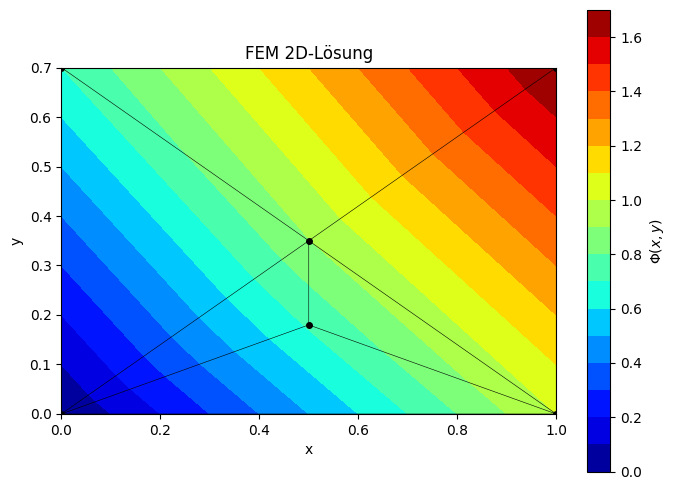

In [10]:
plt.figure(figsize=(7, 5))
plt.tricontourf(p[:, 0], p[:, 1], t, Phi_complete, levels=20, cmap='jet')
plt.colorbar(label=r'$\Phi(x,y)$')
plt.triplot(p[:, 0], p[:, 1], t, color='k', linewidth=0.4)
plt.plot(p[:, 0], p[:, 1], 'k.', markersize=8)
plt.title('FEM 2D-Lösung')
plt.xlabel('x')
plt.ylabel('y')
plt.gca().set_aspect('equal')
plt.tight_layout()
plt.show()

---
## Zusammenfassung: Änderungen gegenüber 1D

### Konzeptuell identisch

- Schwache Form mit Galerkin-Ansatz
- Element-für-Element-Assembly
- Lokale → globale Übersetzung via `t`-Liste
- Akkumulation mit `+=`
- Dirichlet-Reduktion (auf rechte Seite, Zeilen/Spalten streichen)
- LGS-Lösung

### Geometrisch erweitert

- Punkte $(x_i, y_i)$ statt nur $x_i$
- Dreieckselemente statt Intervalle
- 3 lokale Knoten statt 2 → 3×3-Matrix statt 2×2
- 9 Integrale pro Element statt 4
- Gradient $\nabla$ statt nur $d/dx$

### Technisch erweitert

- Sparse-Matrizen (`lil_matrix`, `csr_matrix`) statt dichte Matrizen
- `spsolve` statt `np.linalg.solve`
- 2D-Visualisierung mit `tricontourf` / `triplot`

### Die zentrale Brücke 1D ↔ 2D

Beide Verfahren basieren auf derselben Idee: **Approximiere die Lösung als Linearkombination kompakt unterstützter Hutfunktionen, formuliere die Gleichung schwach, und löse das resultierende LGS**. Die Mathematik bleibt strukturell identisch. Die geometrischen Details werden allerdings komplexer.

Darin liegt der eigentliche Wert der FEM-Architektur: **Mit denselben konzeptuellen Bausteinen lassen sich Probleme beliebiger Dimension und Komplexität bearbeiten.** Das Verständnis für 1D lässt sich direkt auf 2D und 3D übertragen. 

### mögliche Erweiterungen

- **Mesh-Generierung**: automatische Erzeugung von Dreiecksnetzen für komplexere Geometrien (z.B. mit `scipy.spatial.Delaunay` oder `pygmsh`)
- **Konvergenzanalyse**: Mesh verfeinern und Fehler in der Energienorm messen ($\mathcal{O}(h^2)$ erwartet)
- **Robin-Randbedingungen**: Einbau gemischter Rand-Beiträge
- **Vektorfelder**: Edge-Elemente (Nédélec) für 2D-Maxwell-Probleme
- **Eigenwertprobleme**: Resonanzen, Eigenmoden
- **Spektrale Elementemethoden**: Zerlegung des Gebiets in Elemente wie bei FEM. innerhalb jedes Elements werden hochgradige Spektral-Basisfunktionen verwendet (Legendre / Tschebyscheff), was die geometrische Flexibilität der FEM mit der schnellen Konvergenz der Spekralmethoden verbindet (State of the Art für viele Strömungsprobleme)
- **Modale FEM / hierarchische Basen**: Statt nodaler Dachfunktionen verwendet man hierarchische Funktionen, die einem sukzessiven Reihenaufbau ähneln (Verfeinerte Approximation durch höhere Moden , ohne das ganze System neu aufbauen zu müssen
p-Verfeinerung).
- **3D-Erweiterung**: Tetraederelemente mit 4 lokalen Knoten → 4×4-Matrix

- **interessante Erweiterungen**:

- **1.** wenn man die Endknoten zu einem Element verbindet, und darüber die 2 halben Hutfunktionen zu einer komplette verbindet kann man periodische Randbedingungen nutzen. Anwendbar für periodische  Probleme (translatorisch oder rotatorisch) um den Rechenaufwand zu reduzieren. (Symmetrieausnutzung)

- **1.2** Veränderte Bedingung pro Periode
wenn wir die periodischen Ränder verallgemeinern
mit $\Phi(b) = e^{i\theta} \, \Phi(a)$ wobei der Phasenwinkel $\theta$ steuert, wieviel sich pro Zyklus ändert. Jetzt kann man Blochperiodische randbedingungen nutzen. Beispielnutzen: EMV mit winkelabhängigen Schirmstrukturen (Lüftungsgitter bei Normaleinstrahlung und bestimmten Winkeln, welche z.B Resonanzen verursachen können,Thema: Grating Bedingungen und Transmissionsmaximas)